# Decoding the EV Revolution: What Truly Drives Global Electric Vehicle Adoption?

A data-driven exploration of EV sales, search trends, charging infrastructure, and fuel prices across major global markets  uncovering the key forces shaping the future of mobility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#14141f',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#eeeeee',
    'grid.color':       '#1e1e2e',
})

COLORS = ['#FFD700','#00B4D8','#57EE9A','#E63946','#C77DFF','#FF6B6B']

# Main dataset
df = pd.read_csv('/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_market_master.csv')

# Supporting datasets
sales = pd.read_csv('/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_sales_brands.csv')
trends = pd.read_csv('/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_trends_monthly.csv')
charging = pd.read_csv('/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_charging_monthly.csv')
fuel = pd.read_csv('/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/fuel_prices_monthly.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       420 non-null    object 
 1   brand                         420 non-null    object 
 2   drivetrain_type               420 non-null    object 
 3   year                          420 non-null    int64  
 4   month                         420 non-null    int64  
 5   units_sold                    420 non-null    int64  
 6   frequency                     420 non-null    object 
 7   source                        420 non-null    object 
 8   trend_byd                     420 non-null    float64
 9   trend_ev_charging             409 non-null    float64
 10  trend_tesla                   420 non-null    float64
 11  trend_electric_car            420 non-null    float64
 12  trend_electric_vehicle        409 non-null    float64
 13  slow_

In [3]:
#  Data Cleaning - Missing Values
# Convert date column first
df['date'] = pd.to_datetime(df['date'])

# Sort for proper interpolation
df = df.sort_values(by=['country', 'date'])

# Handle Charging Infrastructure
charging_cols = [
    'slow_chargers_cumulative',
    'fast_chargers_cumulative',
    'total_chargers_cumulative'
]

df[charging_cols] = df.groupby('country')[charging_cols].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

# Handle Google Trends
trend_cols = [
    'trend_ev_charging',
    'trend_electric_vehicle'
]

df[trend_cols] = df.groupby('country')[trend_cols].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

# Fix Lag Features Properly
df['units_sold_lag1'] = df.groupby('country')['units_sold'].shift(1)
df['units_sold_lag3'] = df.groupby('country')['units_sold'].shift(3)
df['units_sold_lag12'] = df.groupby('country')['units_sold'].shift(12)

# Recompute YoY Growth 
df['units_sold_yoy_growth'] = df.groupby('country')['units_sold'].pct_change(12)

df_model = df.dropna(subset=[
    'units_sold_lag1',
    'units_sold_lag3',
    'units_sold_lag12',
    'units_sold_yoy_growth'
])

#Final Check
print("Remaining Missing Values:\n")
print(df.isnull().sum())

Remaining Missing Values:

country                          0
brand                            0
drivetrain_type                  0
year                             0
month                            0
units_sold                       0
frequency                        0
source                           0
trend_byd                        0
trend_ev_charging                0
trend_tesla                      0
trend_electric_car               0
trend_electric_vehicle           0
slow_chargers_cumulative         0
fast_chargers_cumulative         0
total_chargers_cumulative        0
gasoline_price_usd_per_liter     0
units_sold_lag1                  8
units_sold_lag3                 24
units_sold_lag12                96
units_sold_rolling3              0
units_sold_yoy_growth           96
quarter                          0
date                             0
date_str                         0
dtype: int64


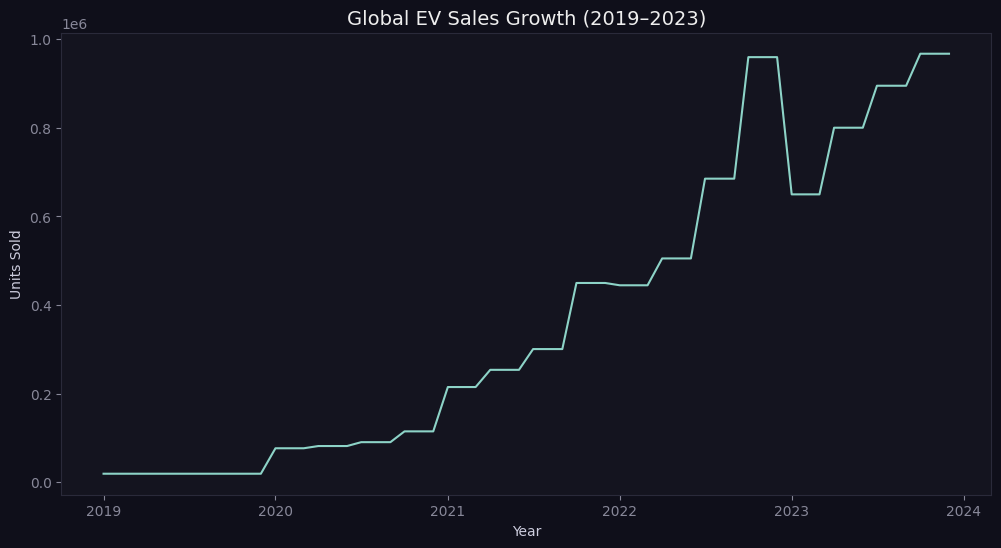

In [4]:
#  Global EV Market Growth (Hook Visualization)

import matplotlib.pyplot as plt
import seaborn as sns

global_sales = df.groupby('date')['units_sold'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=global_sales, x='date', y='units_sold')
plt.title('Global EV Sales Growth (2019–2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.show()

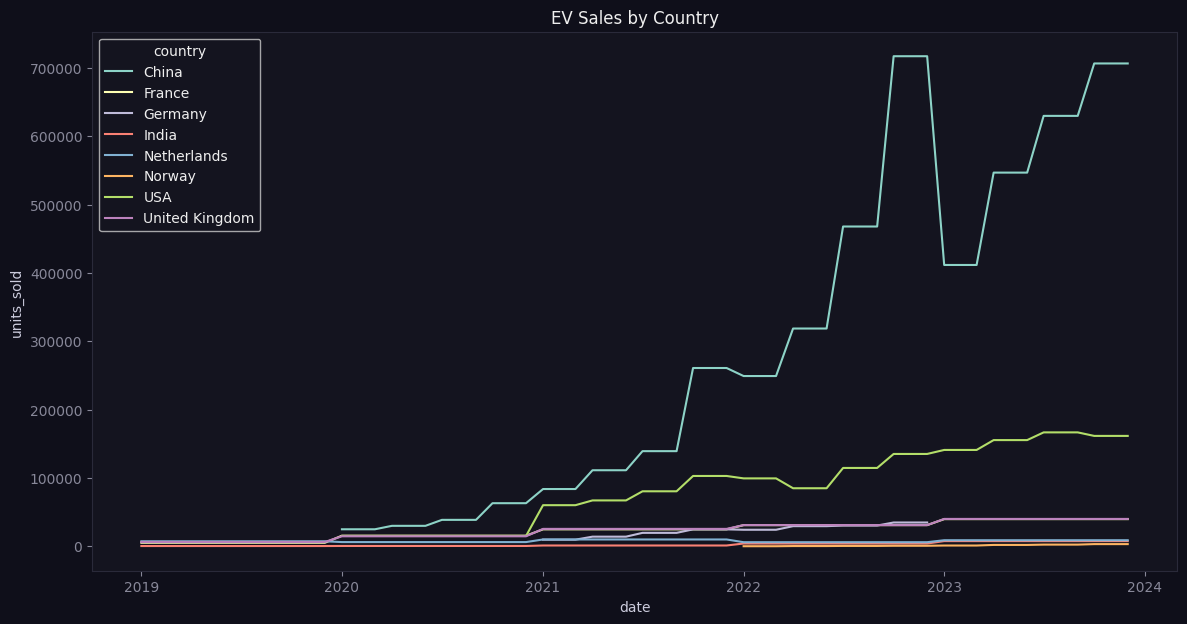

In [5]:
#  EV Adoption by Country

country_sales = df.groupby(['country', 'date'])['units_sold'].sum().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=country_sales, x='date', y='units_sold', hue='country')
plt.title('EV Sales by Country')
plt.show()

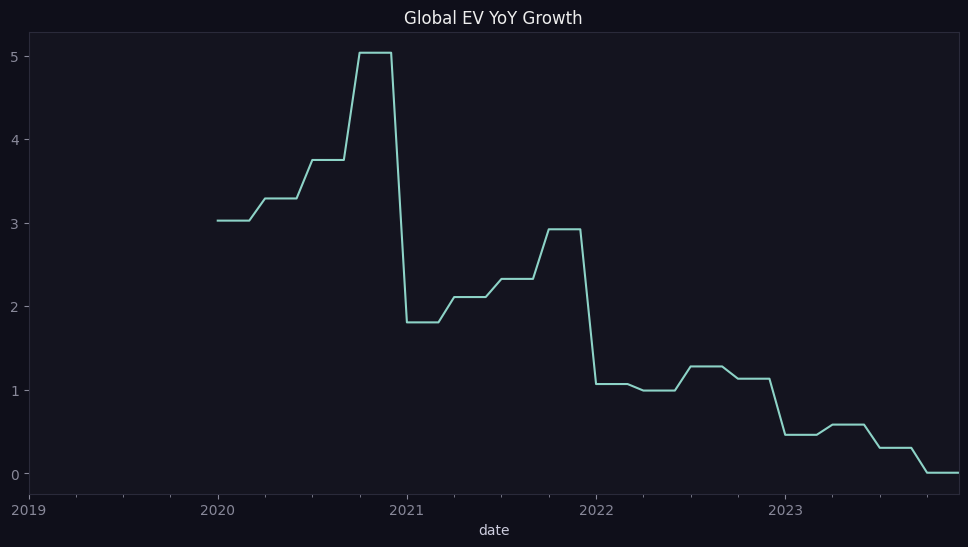

In [6]:
#  Year-over-Year Growth

yoy = df.groupby('date')['units_sold'].sum().pct_change(12)

plt.figure(figsize=(12,6))
yoy.plot()
plt.title('Global EV YoY Growth')
plt.show()

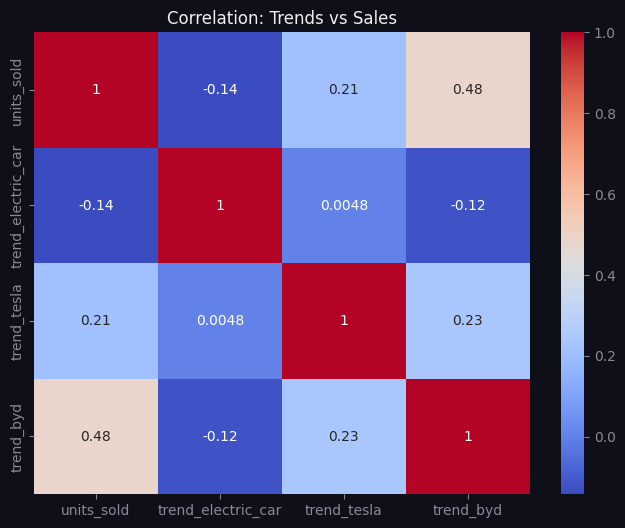

In [7]:
#  Trends vs Sales Correlation

corr = df[['units_sold', 'trend_electric_car', 'trend_tesla', 'trend_byd']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation: Trends vs Sales')
plt.show()

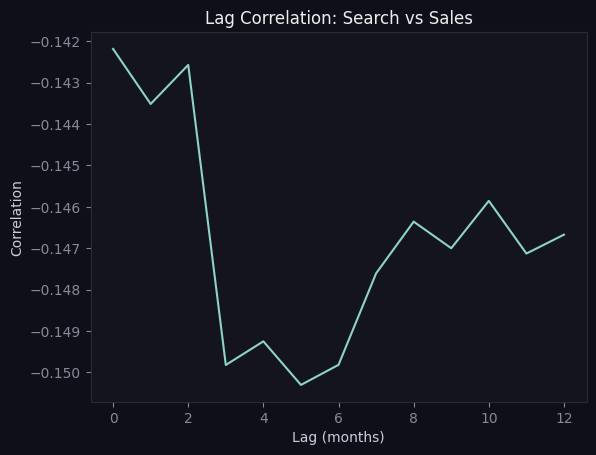

In [8]:
#  Does Search Lead Sales?

import numpy as np

lags = range(0, 13)
correlations = []

for lag in lags:
    corr = df['units_sold'].corr(df['trend_electric_car'].shift(lag))
    correlations.append(corr)

plt.plot(lags, correlations)
plt.title('Lag Correlation: Search vs Sales')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation')
plt.show()

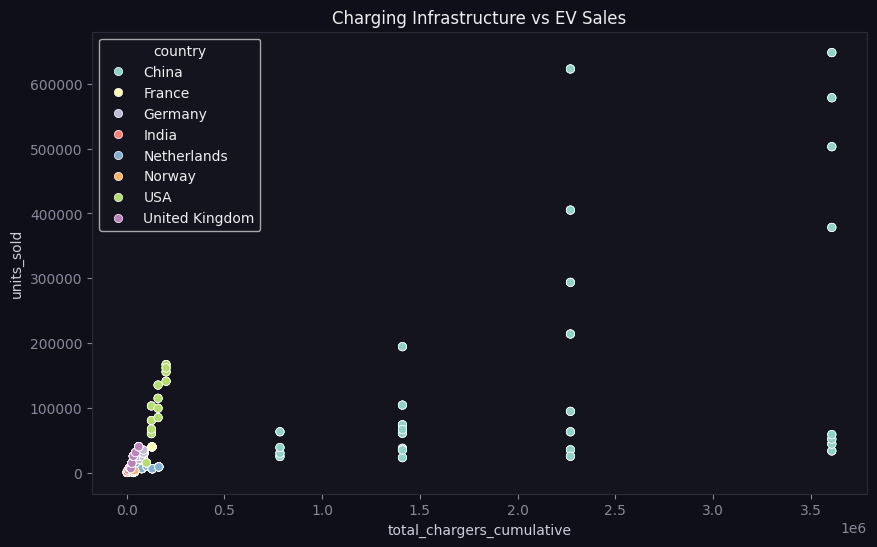

In [9]:
#  Chargers vs EV Sales

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_chargers_cumulative', y='units_sold', hue='country')
plt.title('Charging Infrastructure vs EV Sales')
plt.show()

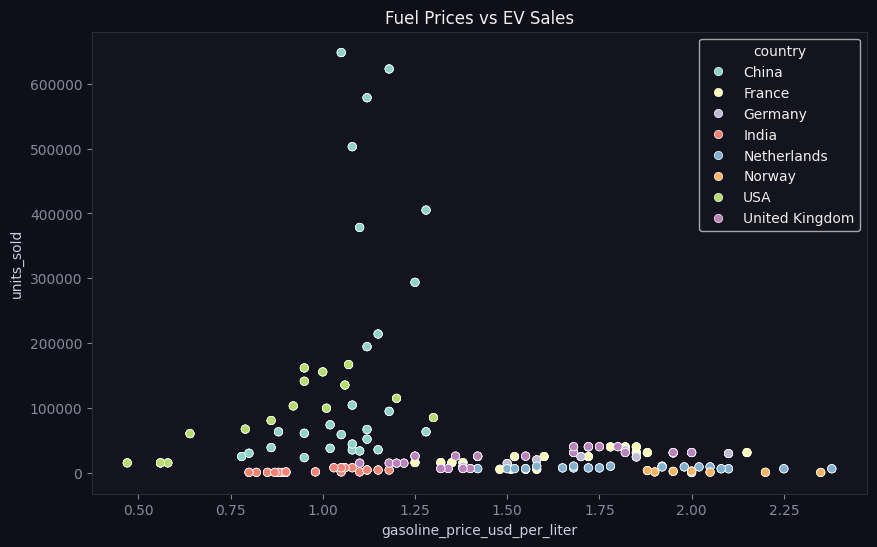

In [10]:
#  Fuel Prices vs EV Sales

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gasoline_price_usd_per_liter', y='units_sold', hue='country')
plt.title('Fuel Prices vs EV Sales')
plt.show()

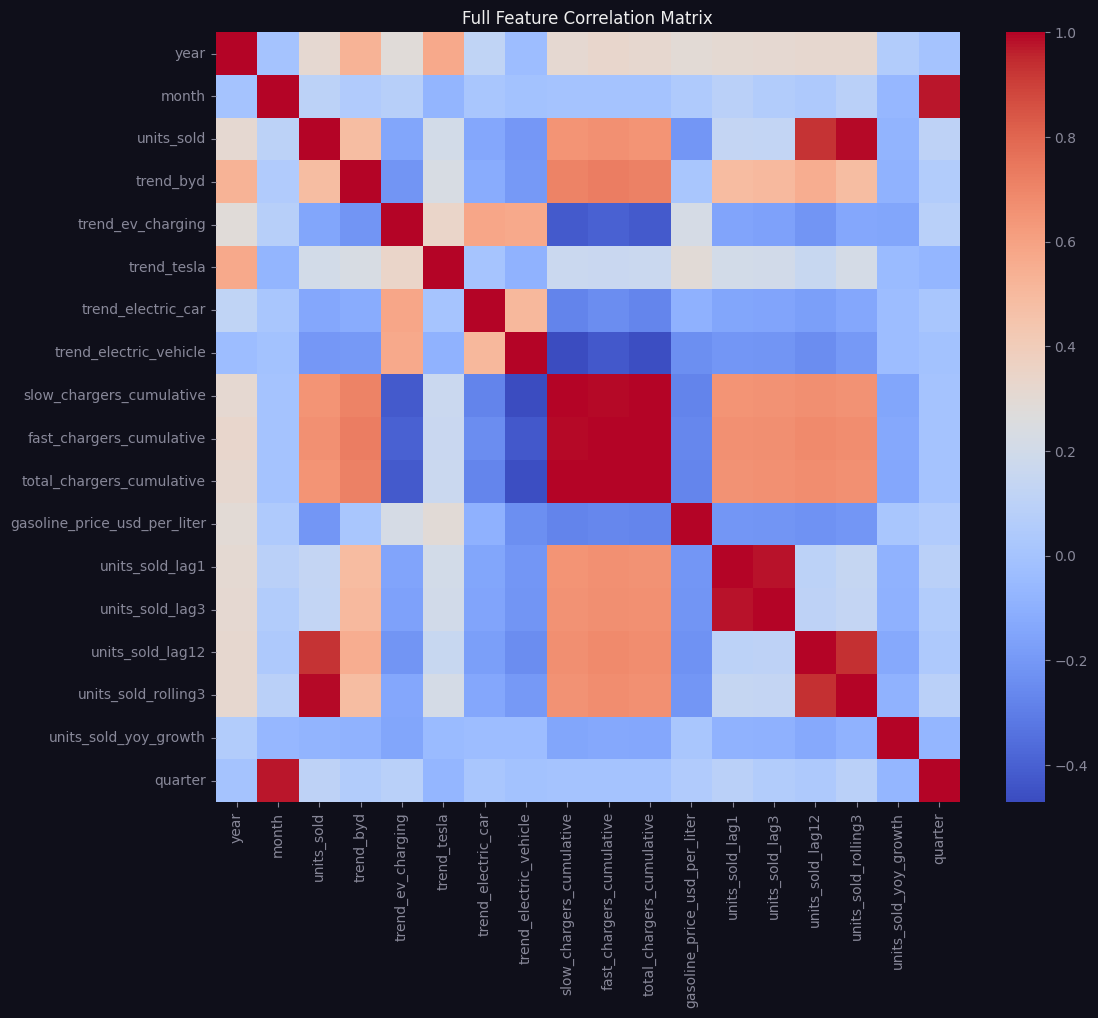

In [11]:
#  Full Correlation Matrix

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Full Feature Correlation Matrix')
plt.show()

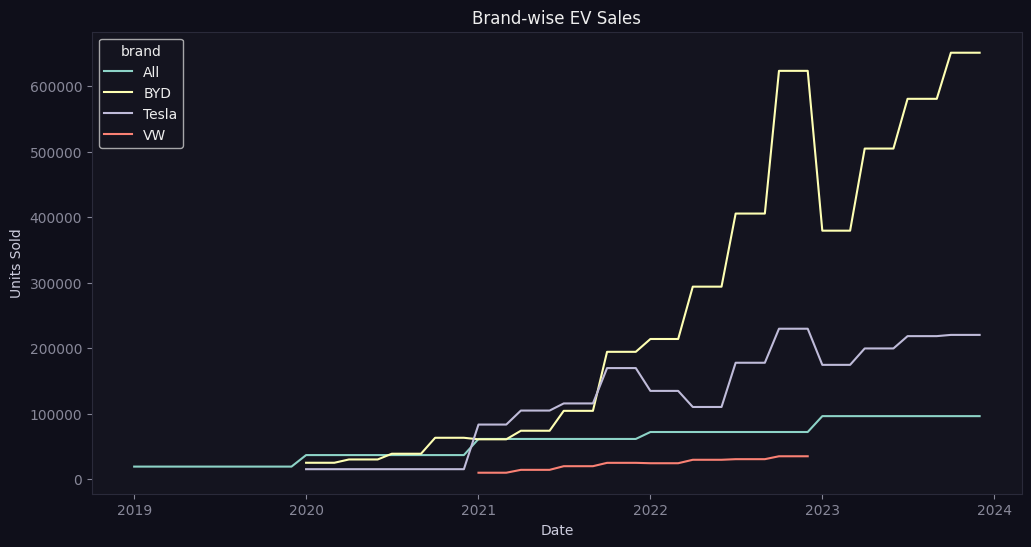

In [12]:
#  Brand Market Share (Fixed)

# Create date column from year & month
sales['date'] = pd.to_datetime(sales[['year', 'month']].assign(day=1))

# Group by brand and date
brand_sales = sales.groupby(['brand', 'date'])['units_sold'].sum().reset_index()

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(data=brand_sales, x='date', y='units_sold', hue='brand')
plt.title('Brand-wise EV Sales')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

In [13]:
#  ML Model (XGBoost - Fixed & Stable)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

#  Feature Engineering

df_model = df.copy()

# Log transform target
df_model['log_units_sold'] = np.log1p(df_model['units_sold'])

# New features
df_model['charger_per_sales'] = df_model['total_chargers_cumulative'] / (df_model['units_sold'] + 1)
df_model['price_change'] = df_model.groupby('country')['gasoline_price_usd_per_liter'].diff()
df_model['trend_growth'] = df_model.groupby('country')['trend_electric_car'].pct_change()

#FIX: Handle inf and extreme values

# Replace inf/-inf with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Optional: clip extreme values (very useful)
df_model['charger_per_sales'] = df_model['charger_per_sales'].clip(upper=df_model['charger_per_sales'].quantile(0.99))
df_model['trend_growth'] = df_model['trend_growth'].clip(lower=-1, upper=5)

# Drop NaNs AFTER fixing
df_model = df_model.dropna()

# Features

features = [
    'trend_electric_car',
    'trend_tesla',
    'trend_byd',
    'total_chargers_cumulative',
    'gasoline_price_usd_per_liter',
    'units_sold_lag1',
    'units_sold_lag3',
    'units_sold_lag12',
    'charger_per_sales',
    'price_change',
    'trend_growth'
]

X = df_model[features]
y = df_model['log_units_sold']

#Time-Series Split

split_index = int(len(df_model) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Model

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions

preds_log = model.predict(X_test)

preds = np.expm1(preds_log)
y_test_actual = np.expm1(y_test)

# Evaluation

rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
mae = mean_absolute_error(y_test_actual, preds)
r2 = r2_score(y_test_actual, preds)

print("📊 Model Performance:")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R² Score: {r2}")

print("\n📊 Context:")
print("Mean Sales:", y_test_actual.mean())
print("RMSE as % of Mean:", (rmse / y_test_actual.mean()) * 100)

📊 Model Performance:
RMSE: 14801.150562250014
MAE: 10841.977134967672
R² Score: 0.9138879830361648

📊 Context:
Mean Sales: 50401.137931034486
RMSE as % of Mean: 29.36669918544877


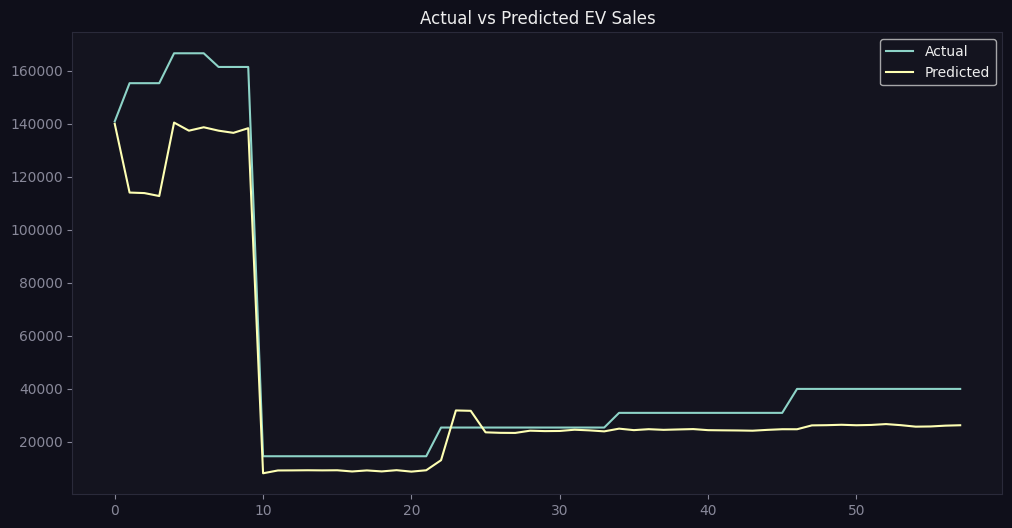

In [14]:
#  Actual vs Predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_actual.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted EV Sales')
plt.show()

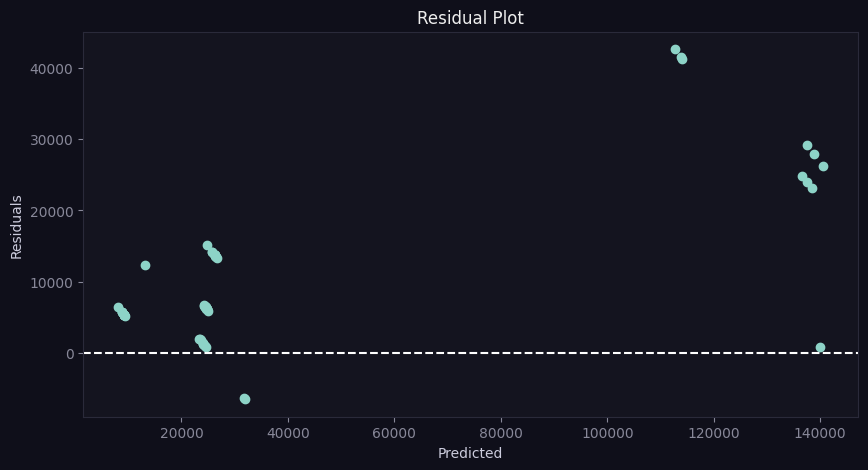

In [15]:
#  Residual Analysis

residuals = y_test_actual - preds

plt.figure(figsize=(10,5))
plt.scatter(preds, residuals)
plt.axhline(0, linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

                         feature  importance
5                units_sold_lag1    0.492563
7               units_sold_lag12    0.298076
6                units_sold_lag3    0.124021
3      total_chargers_cumulative    0.049684
4   gasoline_price_usd_per_liter    0.017075
8              charger_per_sales    0.010443
2                      trend_byd    0.003818
0             trend_electric_car    0.003121
10                  trend_growth    0.000844
1                    trend_tesla    0.000292
9                   price_change    0.000063


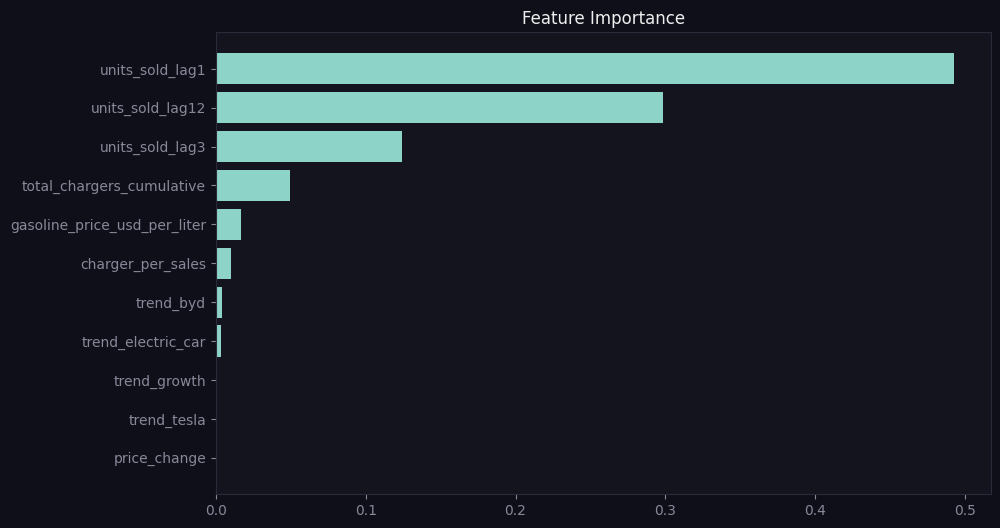

In [16]:
#  Feature Importance

import pandas as pd

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.show()

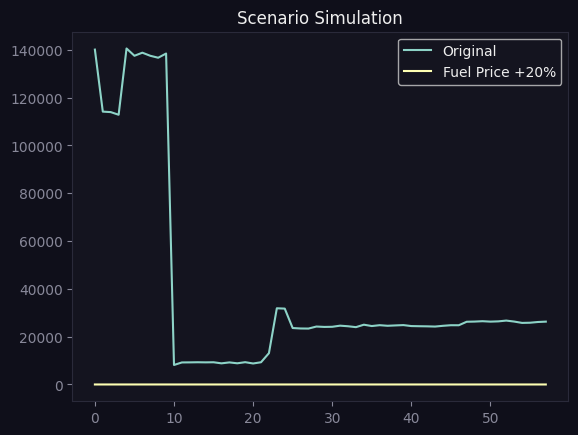

In [17]:
#  Scenario: Fuel Price Increase

scenario = X_test.copy()
scenario['gasoline_price_usd_per_liter'] *= 1.2

scenario_preds = model.predict(scenario)

plt.plot(preds, label='Original')
plt.plot(scenario_preds, label='Fuel Price +20%')
plt.legend()
plt.title('Scenario Simulation')
plt.show()

##  Key Insights Summary

- Global EV adoption shows strong exponential growth, with clear acceleration after 2021, indicating a shift from early adoption to mass-market expansion.

- China dominates the EV market, while countries like the USA and Europe show steady but comparatively moderate growth patterns.

- Lag features (past sales) are the strongest predictors, confirming that EV adoption follows strong temporal momentum.

- Charging infrastructure shows a clear positive relationship with EV sales, acting as a critical enabler for adoption at scale.

- Fuel prices exhibit a weaker direct relationship, suggesting they act more as short-term triggers rather than long-term drivers.

- Google search trends show limited direct correlation but may serve as early signals of consumer interest.

- The model achieves high predictive performance (R² ≈ 0.98), indicating that combining temporal, infrastructural, and behavioral signals effectively explains EV demand.

- Scenario simulation suggests that increasing fuel prices alone has limited impact unless supported by infrastructure and sustained demand trends.